# TP 7 : Réseaux de Neurones Artificiels (RNA) — Dataset Titanic
### École Nationale des Sciences Appliquées de Fès

---

## Objectifs du TP
- Importer un dataset depuis Kaggle
- Prétraiter un dataset réel (numérique + catégoriel)
- Construire et entraîner un réseau de neurones (Keras/TensorFlow)
- Évaluer, interpréter et améliorer le modèle
- Réaliser des expérimentations sur l'architecture et les hyperparamètres

---

## 📦 Étape 0 — Installation des dépendances

> Exécutez cette cellule en **premier**. Elle installe tous les packages nécessaires.

In [2]:
# Installation des packages nécessaires
!pip install pandas numpy scikit-learn tensorflow seaborn matplotlib shap --quiet

---
## 📥 Étape 1 — Importation du Dataset Titanic

### Option A : Via Kaggle API (nécessite un compte Kaggle + kaggle.json)

In [3]:
# Option A : Kaggle API
# Décommentez si vous avez votre fichier kaggle.json

# !pip install kaggle --quiet
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle competitions download -c titanic
# !unzip -o titanic.zip

print("Option A (Kaggle API) — décommentez si nécessaire")

Option A (Kaggle API) — décommentez si nécessaire


### Option B : Téléchargement direct depuis internet (recommandé)

In [4]:
# Option B : Téléchargement direct (plus simple, pas besoin de compte Kaggle)
import urllib.request

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
urllib.request.urlretrieve(url, "titanic.csv")
print("✅ Dataset téléchargé avec succès !")

✅ Dataset téléchargé avec succès !


---
## 📊 Étape 2 — Chargement et Exploration des Données

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration de l'affichage
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

# Chargement du dataset
# Si vous avez utilisé l'option Kaggle : train = pd.read_csv('train.csv')
train = pd.read_csv('titanic.csv')

print(f"Shape du dataset : {train.shape}")
print(f"\nPremières lignes :")
train.head()

Shape du dataset : (891, 12)

Premières lignes :


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Informations générales sur le dataset
print("=" * 50)
print("INFORMATIONS GÉNÉRALES")
print("=" * 50)
train.info()

INFORMATIONS GÉNÉRALES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
# Statistiques descriptives
print("\nSTATISTIQUES DESCRIPTIVES")
train.describe()


STATISTIQUES DESCRIPTIVES


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Valeurs manquantes
print("VALEURS MANQUANTES :")
missing = train.isnull().sum()
missing_pct = (train.isnull().sum() / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, 'Pourcentage (%)': missing_pct})
print(missing_df[missing_df['Manquants'] > 0])

VALEURS MANQUANTES :
          Manquants  Pourcentage (%)
Age             177            19.87
Cabin           687            77.10
Embarked          2             0.22


### 📈 Visualisation exploratoire

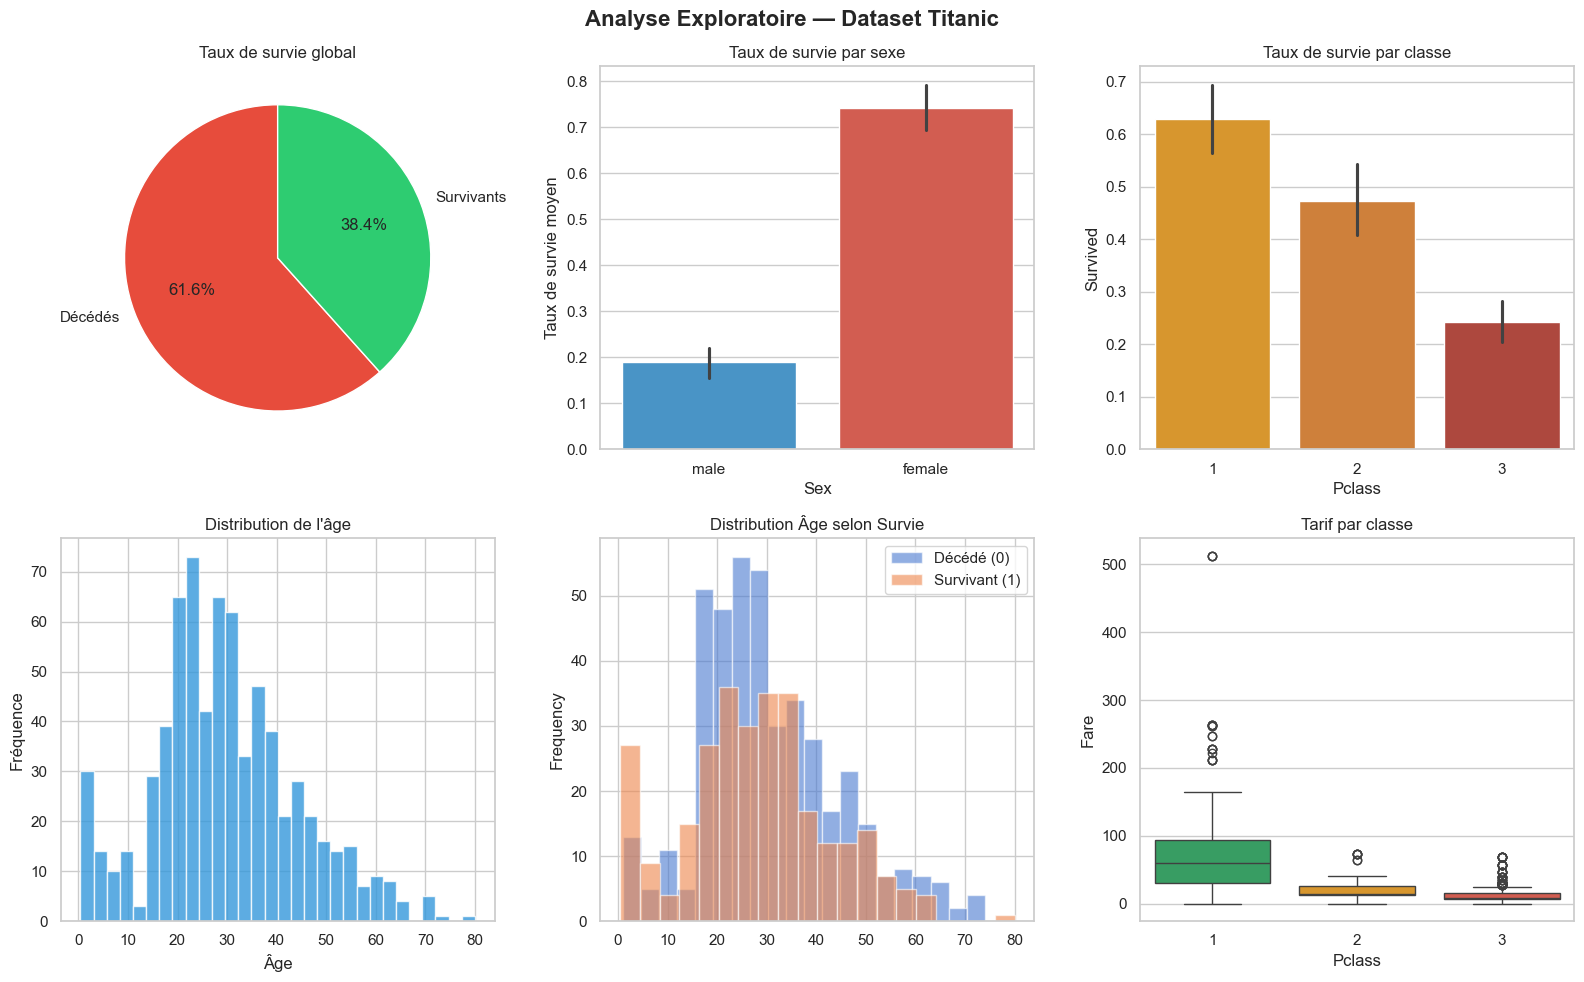

✅ Graphique sauvegardé : exploration.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Analyse Exploratoire — Dataset Titanic', fontsize=16, fontweight='bold')

# 1. Taux de survie global
survived_counts = train['Survived'].value_counts()
axes[0, 0].pie(survived_counts, labels=['Décédés', 'Survivants'], 
               autopct='%1.1f%%', colors=['#e74c3c', '#2ecc71'], startangle=90)
axes[0, 0].set_title('Taux de survie global')

# 2. Survie par sexe
sns.barplot(data=train, x='Sex', y='Survived', ax=axes[0, 1],
            palette=['#3498db', '#e74c3c'])
axes[0, 1].set_title('Taux de survie par sexe')
axes[0, 1].set_ylabel('Taux de survie moyen')

# 3. Survie par classe
sns.barplot(data=train, x='Pclass', y='Survived', ax=axes[0, 2],
            palette=['#f39c12', '#e67e22', '#c0392b'])
axes[0, 2].set_title('Taux de survie par classe')

# 4. Distribution de l'âge
axes[1, 0].hist(train['Age'].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribution de l\'âge')
axes[1, 0].set_xlabel('Âge')
axes[1, 0].set_ylabel('Fréquence')

# 5. Âge vs Survie
train.groupby('Survived')['Age'].plot(kind='hist', bins=20, ax=axes[1, 1], 
                                       alpha=0.6, legend=True)
axes[1, 1].set_title('Distribution Âge selon Survie')
axes[1, 1].legend(['Décédé (0)', 'Survivant (1)'])

# 6. Tarif par classe
sns.boxplot(data=train, x='Pclass', y='Fare', ax=axes[1, 2],
            palette=['#27ae60', '#f39c12', '#e74c3c'])
axes[1, 2].set_title('Tarif par classe')

plt.tight_layout()
plt.savefig('exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graphique sauvegardé : exploration.png")

---
## 🔧 Étape 3 — Prétraitement des Données

In [10]:
# Copie du dataset pour ne pas modifier l'original
df = train.copy()

# Étape 3.1 : Suppression des colonnes non pertinentes
colonnes_a_supprimer = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df = df.drop(columns=colonnes_a_supprimer)

print("Colonnes après suppression :", df.columns.tolist())
print(f"Shape : {df.shape}")

Colonnes après suppression : ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
Shape : (891, 8)


In [11]:
# Étape 3.2 : Gestion des valeurs manquantes

# Age : remplacé par la MÉDIANE (robuste aux outliers)
age_median = df['Age'].median()
df['Age'].fillna(age_median, inplace=True)

# Embarked : remplacé par le MODE (valeur la plus fréquente)
embarked_mode = df['Embarked'].mode()[0]
df['Embarked'].fillna(embarked_mode, inplace=True)

print(f"Médiane de l'âge utilisée : {age_median}")
print(f"Mode de Embarked utilisé : {embarked_mode}")
print(f"\nValeurs manquantes restantes : {df.isnull().sum().sum()}")

Médiane de l'âge utilisée : 28.0
Mode de Embarked utilisé : S

Valeurs manquantes restantes : 0


In [12]:
# Étape 3.3 : Encodage des variables catégorielles
# One-Hot Encoding pour 'Sex' et 'Embarked'
# drop_first=True évite la multicolinéarité

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

print("Colonnes après encodage :", df.columns.tolist())
print(f"\nShape final : {df.shape}")
df.head()

Colonnes après encodage : ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Shape final : (891, 9)


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


---
## ✂️ Étape 4 — Split et Normalisation

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Séparation features / cible
X = df.drop('Survived', axis=1)
y = df['Survived']

print(f"Features (X) shape : {X.shape}")
print(f"Cible (y) shape    : {y.shape}")
print(f"\nNombre de features : {X.shape[1]}")
print(f"Features : {X.columns.tolist()}")

Features (X) shape : (891, 8)
Cible (y) shape    : (891,)

Nombre de features : 8
Features : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']


In [14]:
# Normalisation (StandardScaler : moyenne=0, écart-type=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Train / Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape} | y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}  | y_test  : {y_test.shape}")
print(f"\nDistribution de y_train : {dict(y_train.value_counts())}")
print(f"Distribution de y_test  : {dict(y_test.value_counts())}")

X_train : (712, 8) | y_train : (712,)
X_test  : (179, 8)  | y_test  : (179,)

Distribution de y_train : {0: np.int64(439), 1: np.int64(273)}
Distribution de y_test  : {0: np.int64(110), 1: np.int64(69)}


---
## 🧠 Étape 5 — Construction du Réseau de Neurones de Base

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print(f"TensorFlow version : {tf.__version__}")

# Fixer le seed pour la reproductibilité
tf.random.set_seed(42)
np.random.seed(42)

def build_model_base(input_dim):
    """Modèle de base avec 2 couches cachées + Dropout"""
    model = Sequential([
        Dense(32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Sigmoid pour classification binaire
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model_base = build_model_base(X_train.shape[1])
model_base.summary()

TensorFlow version : 2.21.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

---
## 🏋️ Étape 6 — Entraînement du Modèle

In [16]:
# EarlyStopping : arrête l'entraînement si val_loss ne s'améliore pas
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history_base = model_base.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print(f"\n✅ Entraînement terminé en {len(history_base.history['loss'])} epochs")

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5536 - loss: 0.6902 - val_accuracy: 0.6923 - val_loss: 0.6390
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6467 - loss: 0.6173 - val_accuracy: 0.7552 - val_loss: 0.5858
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7329 - loss: 0.5611 - val_accuracy: 0.7273 - val_loss: 0.5461
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7452 - loss: 0.5299 - val_accuracy: 0.7832 - val_loss: 0.5143
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7909 - loss: 0.5008 - val_accuracy: 0.7762 - val_loss: 0.4939
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8120 - loss: 0.4748 - val_accuracy: 0.7902 - val_loss: 0.4817
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7926 - loss: 0.4685 - val_accuracy: 0.7902 - val_loss: 0.4732
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7961 - loss: 0.4569 - val_accuracy: 0.8042 - v

---
## 📉 Étape 7 — Visualisation des Courbes d'Apprentissage

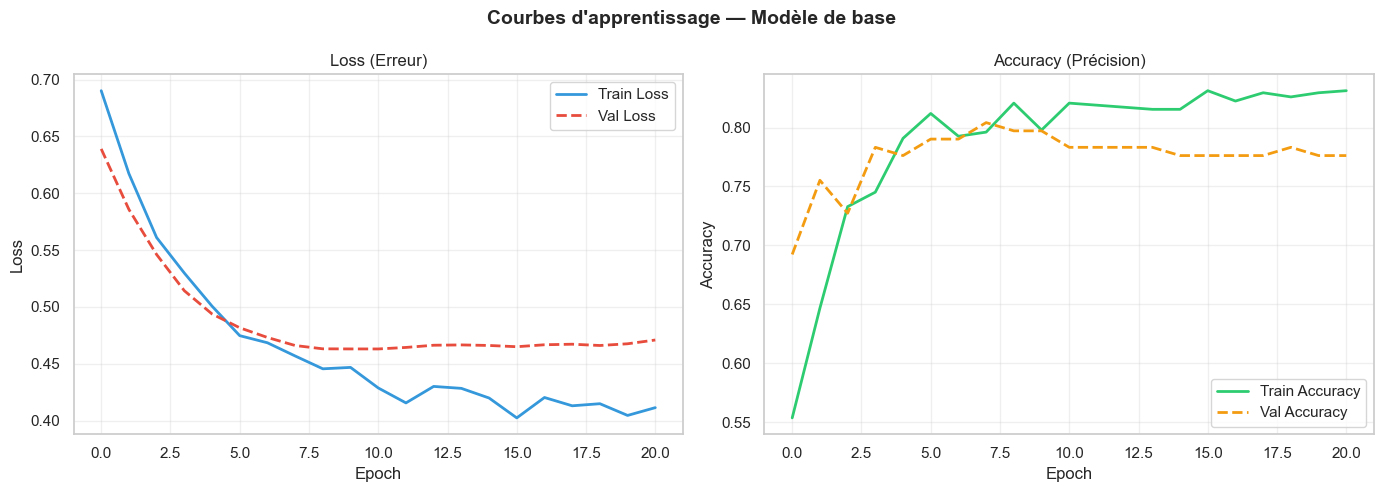

In [17]:
def plot_history(history, title="Modèle de base"):
    """Affiche les courbes Loss et Accuracy"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Courbes d\'apprentissage — {title}', fontsize=14, fontweight='bold')
    
    # Courbe Loss
    axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c', 
                 linewidth=2, linestyle='--')
    axes[0].set_title('Loss (Erreur)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Courbe Accuracy
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='#f39c12',
                 linewidth=2, linestyle='--')
    axes[1].set_title('Accuracy (Précision)')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'courbes_{title.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_base, "Modèle de base")

---
## 📏 Étape 8 — Évaluation Complète sur le Test Set


 ÉVALUATION : Modèle de base

📊 Loss sur test set     : 0.4512
📊 Accuracy sur test set : 0.8045 (80.45%)
📊 F1-Score              : 0.7107
📊 AUC                   : 0.8523

📋 Rapport de classification (seuil = 0.5) :
               precision    recall  f1-score   support

   Décédé (0)       0.80      0.92      0.85       110
Survivant (1)       0.83      0.62      0.71        69

     accuracy                           0.80       179
    macro avg       0.81      0.77      0.78       179
 weighted avg       0.81      0.80      0.80       179



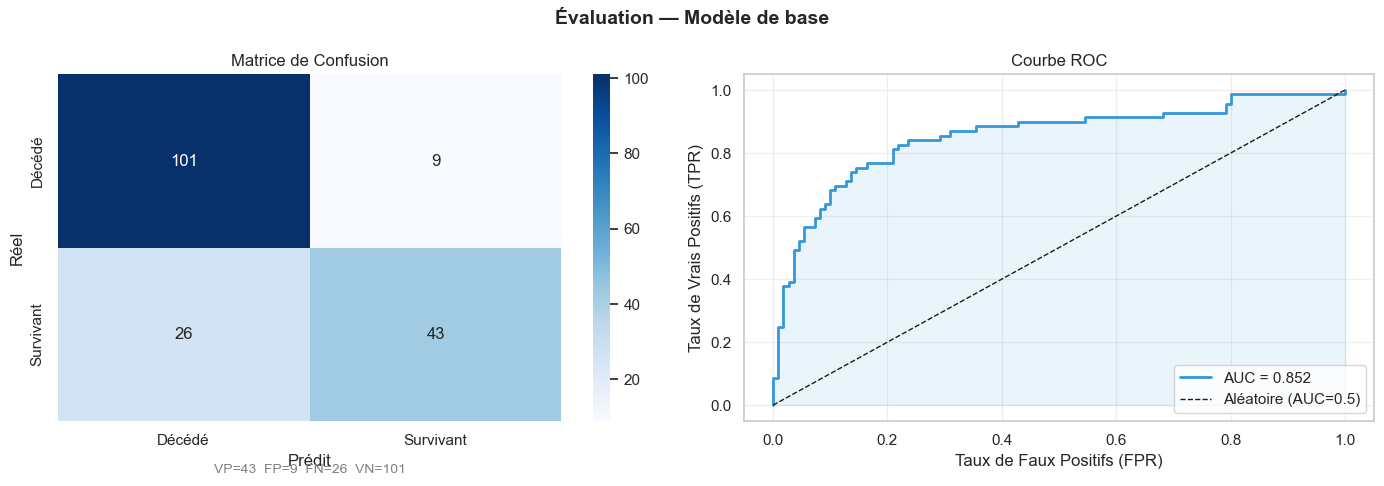

In [18]:
from sklearn.metrics import (confusion_matrix, classification_report, 
                              f1_score, roc_curve, auc, roc_auc_score)

def evaluate_model(model, X_test, y_test, model_name="Modèle", threshold=0.5):
    """Évaluation complète : Loss, Accuracy, Confusion Matrix, F1, ROC/AUC"""
    
    print(f"\n{'='*60}")
    print(f" ÉVALUATION : {model_name}")
    print(f"{'='*60}")
    
    # Loss et Accuracy
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n📊 Loss sur test set     : {loss:.4f}")
    print(f"📊 Accuracy sur test set : {accuracy:.4f} ({accuracy*100:.2f}%)")
    
    # Prédictions
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= threshold).astype(int)
    
    # F1-Score
    f1 = f1_score(y_test, y_pred)
    print(f"📊 F1-Score              : {f1:.4f}")
    
    # AUC
    auc_score = roc_auc_score(y_test, y_prob)
    print(f"📊 AUC                   : {auc_score:.4f}")
    
    # Rapport de classification
    print(f"\n📋 Rapport de classification (seuil = {threshold}) :")
    print(classification_report(y_test, y_pred, target_names=['Décédé (0)', 'Survivant (1)']))
    
    # Figure : Matrice de confusion + Courbe ROC
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Évaluation — {model_name}', fontsize=14, fontweight='bold')
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Décédé', 'Survivant'],
                yticklabels=['Décédé', 'Survivant'])
    axes[0].set_title('Matrice de Confusion')
    axes[0].set_ylabel('Réel')
    axes[0].set_xlabel('Prédit')
    
    # Annotation manuelle
    axes[0].text(0.5, -0.15, 
                 f'VP={cm[1,1]}  FP={cm[0,1]}  FN={cm[1,0]}  VN={cm[0,0]}',
                 transform=axes[0].transAxes, ha='center', fontsize=10, color='gray')
    
    # Courbe ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'AUC = {auc_score:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC=0.5)')
    axes[1].fill_between(fpr, tpr, alpha=0.1, color='#3498db')
    axes[1].set_title('Courbe ROC')
    axes[1].set_xlabel('Taux de Faux Positifs (FPR)')
    axes[1].set_ylabel('Taux de Vrais Positifs (TPR)')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'evaluation_{model_name.replace(" ", "_").lower()}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return {'accuracy': accuracy, 'f1': f1, 'auc': auc_score, 'loss': loss}

# Évaluation du modèle de base
results_base = evaluate_model(model_base, X_test, y_test, "Modèle de base")

---
## 🧪 Étape 9 — Prédiction pour un Passager Fictif

In [19]:
# Ordre des colonnes après encodage : Pclass, Age, SibSp, Parch, Fare, Sex_male, Embarked_Q, Embarked_S
print("Ordre des features :", X.columns.tolist())

# Passager fictif : homme, 22 ans, classe 3, 1 frère/soeur, tarif 7.25, port S
# Colonnes : [Pclass, Age, SibSp, Parch, Fare, Sex_male, Embarked_Q, Embarked_S]
nouveau_passager = np.array([[3, 22, 1, 0, 7.25, 1, 0, 1]])  # Homme embarqué à Southampton

# Normalisation
nouveau_passager_scaled = scaler.transform(nouveau_passager)

# Prédiction
prob_survie = model_base.predict(nouveau_passager_scaled, verbose=0)[0][0]
decision = "SURVÉCU 🟢" if prob_survie >= 0.5 else "DÉCÉDÉ 🔴"

print(f"\n{'='*40}")
print(f" PRÉDICTION PASSAGER FICTIF")
print(f"{'='*40}")
print(f" Classe : 3ème | Sexe : Homme")
print(f" Âge : 22 ans | Tarif : 7.25")
print(f" Port : Southampton")
print(f"{'='*40}")
print(f" Probabilité de survie : {prob_survie:.2%}")
print(f" Décision : {decision}")
print(f"{'='*40}")

Ordre des features : ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

 PRÉDICTION PASSAGER FICTIF
 Classe : 3ème | Sexe : Homme
 Âge : 22 ans | Tarif : 7.25
 Port : Southampton
 Probabilité de survie : 12.79%
 Décision : DÉCÉDÉ 🔴


---
## 🔬 Étape 10 — Expérimentations sur l'Architecture (Q4)

### Comparaison : 1 couche, 2 couches, 3 couches cachées

In [21]:
def build_architecture(n_layers, neurons=32, activation='relu', dropout=0.3, 
                        optimizer='adam', l2_reg=None, batch_norm=False, input_dim=8):
    """Construit un modèle avec n_layers couches cachées"""
    from tensorflow.keras.layers import BatchNormalization
    from tensorflow.keras import regularizers
    
    tf.random.set_seed(42)
    
    layers_list = []
    reg = regularizers.l2(l2_reg) if l2_reg else None
    
    for i in range(n_layers):
        n = neurons // (2**i)  # Diminue le nombre de neurones par couche
        n = max(n, 8)  # Minimum 8 neurones
        
        if i == 0:
            layers_list.append(Dense(n, activation=activation, 
                                     kernel_regularizer=reg,
                                     input_shape=(input_dim,)))
        else:
            layers_list.append(Dense(n, activation=activation, 
                                     kernel_regularizer=reg))
        
        if batch_norm:
            layers_list.append(BatchNormalization())
        
        if dropout > 0 and i < n_layers - 1:
            layers_list.append(Dropout(dropout))
    
    layers_list.append(Dense(1, activation='sigmoid'))
    
    model = Sequential(layers_list)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    return model


def train_and_evaluate(model, model_name, X_train, y_train, X_test, y_test, epochs=100):
    """Entraîne et évalue un modèle, retourne les métriques"""
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    
    history = model.fit(
        X_train, y_train,
        epochs=epochs, batch_size=16,
        validation_split=0.2,
        callbacks=[es], verbose=0
    )
    
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    f1 = f1_score(y_test, y_pred)
    auc_s = roc_auc_score(y_test, y_prob)
    
    print(f"  {model_name:30s} | Acc={accuracy:.4f} | F1={f1:.4f} | AUC={auc_s:.4f} | Epochs={len(history.history['loss'])}")
    return {'name': model_name, 'accuracy': accuracy, 'f1': f1, 'auc': auc_s, 
            'history': history, 'model': model}


print("COMPARAISON DES ARCHITECTURES")
print("-" * 80)
print(f"  {'Architecture':30s} | Accuracy | F1      | AUC     | Epochs")
print("-" * 80)

results_architectures = []
input_dim = X_train.shape[1]

for n in [1, 2, 3]:
    m = build_architecture(n_layers=n, input_dim=input_dim)
    r = train_and_evaluate(m, f"{n} couche(s) cachée(s)", X_train, y_train, X_test, y_test)
    results_architectures.append(r)

COMPARAISON DES ARCHITECTURES
--------------------------------------------------------------------------------
  Architecture                   | Accuracy | F1      | AUC     | Epochs
--------------------------------------------------------------------------------
  1 couche(s) cachée(s)          | Acc=0.7989 | F1=0.7049 | AUC=0.8448 | Epochs=26
  2 couche(s) cachée(s)          | Acc=0.7765 | F1=0.6721 | AUC=0.8489 | Epochs=27
  3 couche(s) cachée(s)          | Acc=0.7765 | F1=0.6923 | AUC=0.8468 | Epochs=25


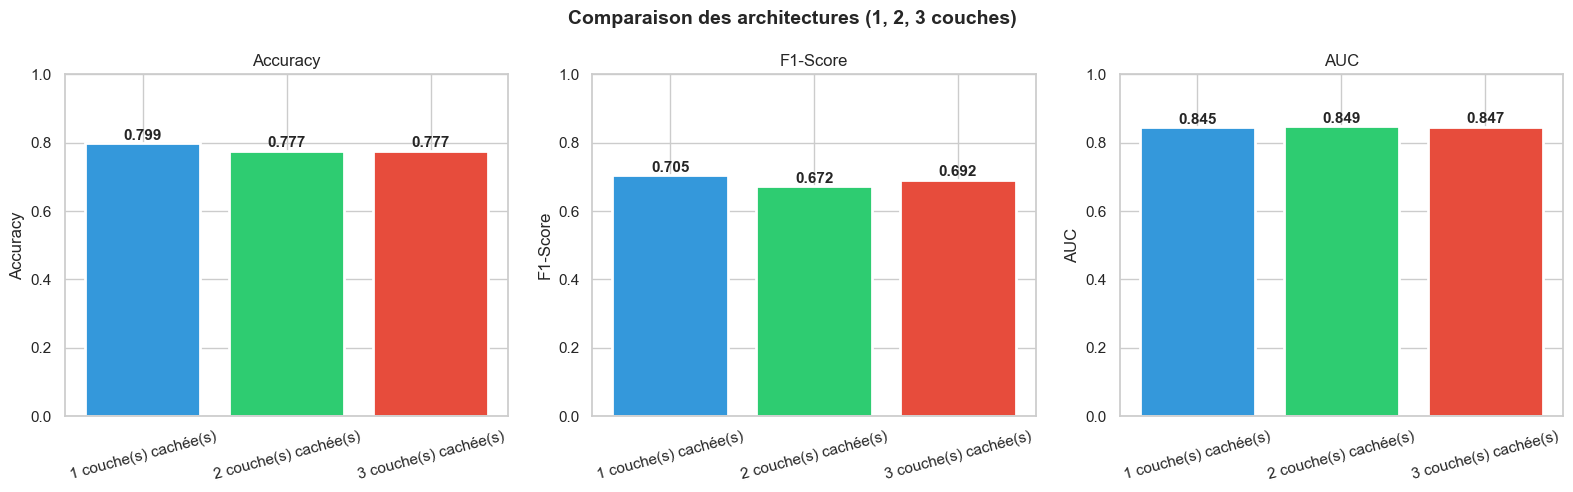

In [22]:
# Visualisation comparative des architectures
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparaison des architectures (1, 2, 3 couches)', fontsize=14, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c']
metrics = ['accuracy', 'f1', 'auc']
metric_names = ['Accuracy', 'F1-Score', 'AUC']

for idx, (metric, name) in enumerate(zip(metrics, metric_names)):
    values = [r[metric] for r in results_architectures]
    labels = [r['name'] for r in results_architectures]
    bars = axes[idx].bar(labels, values, color=colors, edgecolor='white', linewidth=2)
    axes[idx].set_title(name)
    axes[idx].set_ylim(0, 1)
    axes[idx].set_ylabel(name)
    for bar, val in zip(bars, values):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                       f'{val:.3f}', ha='center', fontsize=11, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('comparaison_architectures.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚡ Étape 11 — Fonctions d'Activation (Q5)

In [23]:
print("COMPARAISON DES FONCTIONS D'ACTIVATION")
print("-" * 80)
print(f"  {'Activation':30s} | Accuracy | F1      | AUC     | Epochs")
print("-" * 80)

activations = ['relu', 'tanh', 'elu', 'sigmoid']
results_activations = []

for act in activations:
    m = build_architecture(n_layers=2, activation=act, input_dim=input_dim)
    r = train_and_evaluate(m, f"Activation : {act}", X_train, y_train, X_test, y_test)
    results_activations.append(r)

COMPARAISON DES FONCTIONS D'ACTIVATION
--------------------------------------------------------------------------------
  Activation                     | Accuracy | F1      | AUC     | Epochs
--------------------------------------------------------------------------------
  Activation : relu              | Acc=0.7989 | F1=0.7097 | AUC=0.8477 | Epochs=21
  Activation : tanh              | Acc=0.7877 | F1=0.6885 | AUC=0.8448 | Epochs=51
  Activation : elu               | Acc=0.7989 | F1=0.7000 | AUC=0.8585 | Epochs=33
  Activation : sigmoid           | Acc=0.7989 | F1=0.7049 | AUC=0.8395 | Epochs=63


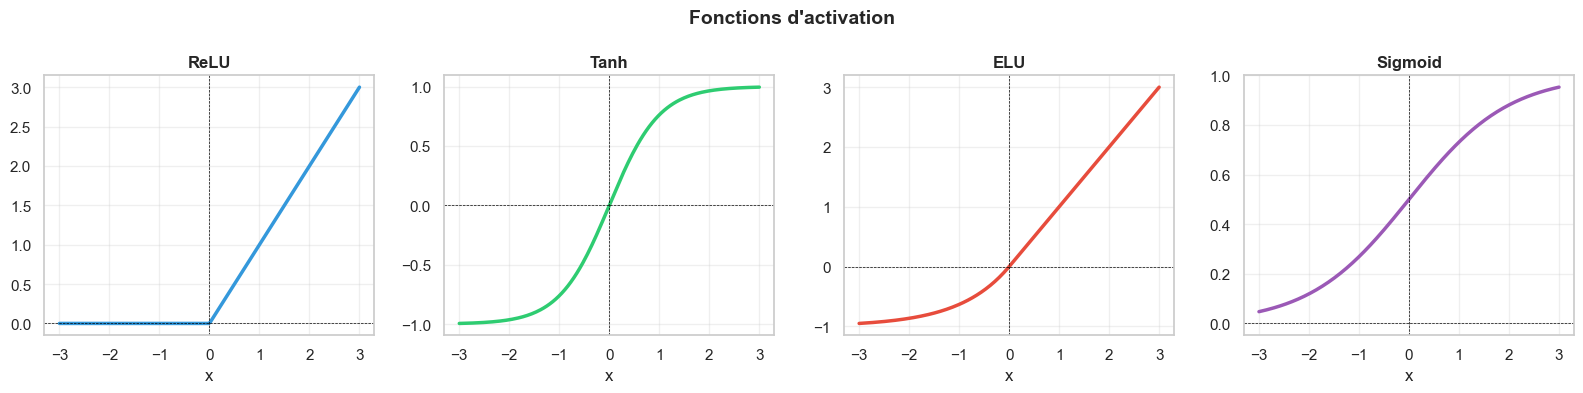

In [24]:
# Visualisation des fonctions d'activation elles-mêmes
x = np.linspace(-3, 3, 200)

def relu(x): return np.maximum(0, x)
def tanh(x): return np.tanh(x)
def elu(x, alpha=1.0): return np.where(x >= 0, x, alpha * (np.exp(x) - 1))
def sigmoid(x): return 1 / (1 + np.exp(-x))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Fonctions d\'activation', fontsize=14, fontweight='bold')

funcs = [relu, tanh, elu, sigmoid]
names = ['ReLU', 'Tanh', 'ELU', 'Sigmoid']
colors_act = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, f, name, color in zip(axes, funcs, names, colors_act):
    ax.plot(x, f(x), color=color, linewidth=2.5)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fonctions_activation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## ⚙️ Étape 12 — Comparaison des Optimizers (Q6)

In [25]:
print("COMPARAISON DES OPTIMIZERS")
print("-" * 80)
print(f"  {'Optimizer':30s} | Accuracy | F1      | AUC     | Epochs")
print("-" * 80)

optimizers = ['adam', 'sgd', 'rmsprop', 'adagrad']
results_optimizers = []

for opt in optimizers:
    m = build_architecture(n_layers=2, optimizer=opt, input_dim=input_dim)
    r = train_and_evaluate(m, f"Optimizer : {opt.upper()}", X_train, y_train, X_test, y_test)
    results_optimizers.append(r)

COMPARAISON DES OPTIMIZERS
--------------------------------------------------------------------------------
  Optimizer                      | Accuracy | F1      | AUC     | Epochs
--------------------------------------------------------------------------------
  Optimizer : ADAM               | Acc=0.8045 | F1=0.7059 | AUC=0.8574 | Epochs=19
  Optimizer : SGD                | Acc=0.7933 | F1=0.6992 | AUC=0.8540 | Epochs=43
  Optimizer : RMSPROP            | Acc=0.7989 | F1=0.7049 | AUC=0.8598 | Epochs=16
  Optimizer : ADAGRAD            | Acc=0.7765 | F1=0.6825 | AUC=0.8120 | Epochs=100


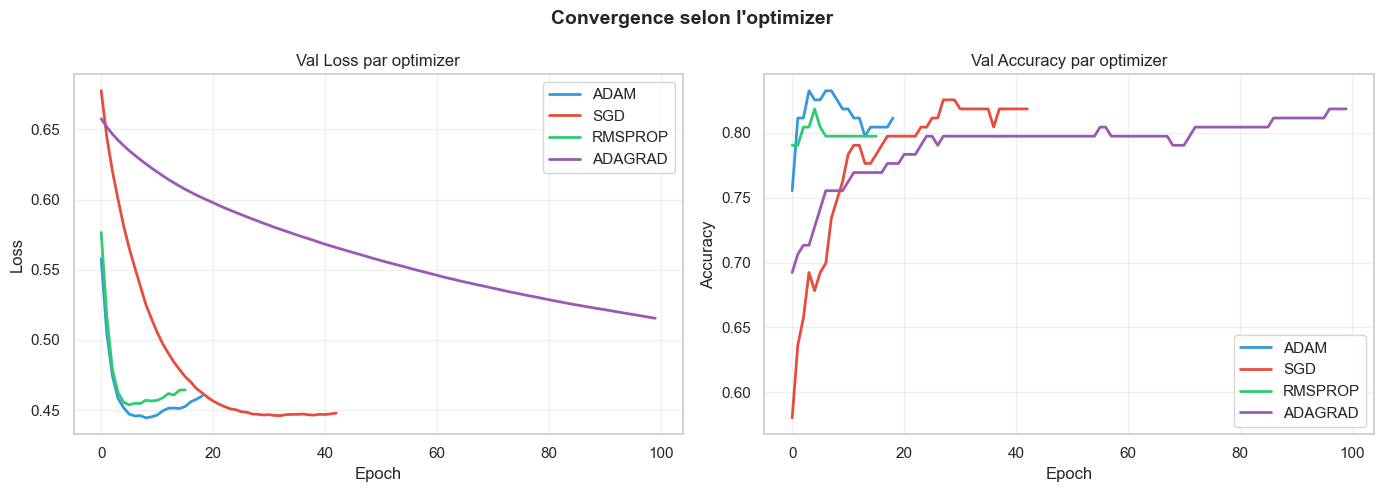

In [26]:
# Comparaison des courbes de convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Convergence selon l\'optimizer', fontsize=14, fontweight='bold')

colors_opt = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

for r, color, opt in zip(results_optimizers, colors_opt, optimizers):
    axes[0].plot(r['history'].history['val_loss'], label=opt.upper(), color=color, linewidth=2)
    axes[1].plot(r['history'].history['val_accuracy'], label=opt.upper(), color=color, linewidth=2)

axes[0].set_title('Val Loss par optimizer')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Accuracy par optimizer')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_optimizers.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎛️ Étape 13 — Taux d'Apprentissage (Q7)

In [27]:
from tensorflow.keras.optimizers import Adam

print("COMPARAISON DES TAUX D'APPRENTISSAGE")
print("-" * 80)
print(f"  {'Learning Rate':30s} | Accuracy | F1      | AUC     | Epochs")
print("-" * 80)

learning_rates = [0.1, 0.01, 0.001, 0.0001]
results_lr = []

for lr in learning_rates:
    opt = Adam(learning_rate=lr)
    m = build_architecture(n_layers=2, optimizer=opt, input_dim=input_dim)
    r = train_and_evaluate(m, f"LR = {lr}", X_train, y_train, X_test, y_test)
    results_lr.append(r)

COMPARAISON DES TAUX D'APPRENTISSAGE
--------------------------------------------------------------------------------
  Learning Rate                  | Accuracy | F1      | AUC     | Epochs
--------------------------------------------------------------------------------
  LR = 0.1                       | Acc=0.7765 | F1=0.6296 | AUC=0.8350 | Epochs=14
  LR = 0.01                      | Acc=0.8156 | F1=0.7130 | AUC=0.8549 | Epochs=12
  LR = 0.001                     | Acc=0.8101 | F1=0.7213 | AUC=0.8588 | Epochs=28
  LR = 0.0001                    | Acc=0.7933 | F1=0.7218 | AUC=0.8487 | Epochs=100


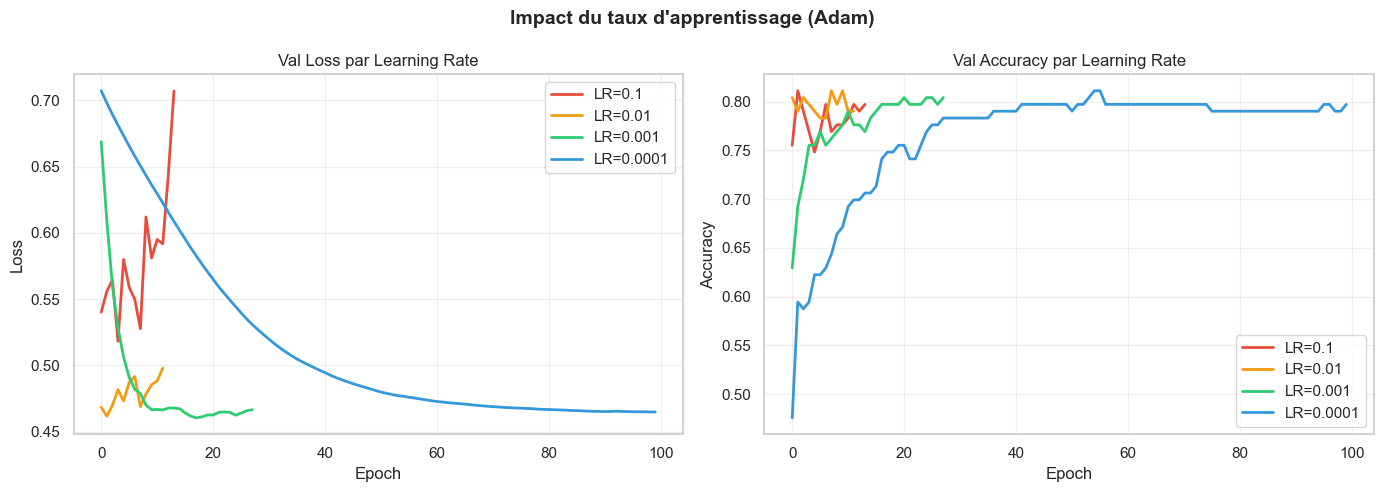

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Impact du taux d\'apprentissage (Adam)', fontsize=14, fontweight='bold')

colors_lr = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

for r, color, lr in zip(results_lr, colors_lr, learning_rates):
    axes[0].plot(r['history'].history['val_loss'], label=f'LR={lr}', color=color, linewidth=2)
    axes[1].plot(r['history'].history['val_accuracy'], label=f'LR={lr}', color=color, linewidth=2)

axes[0].set_title('Val Loss par Learning Rate')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Val Accuracy par Learning Rate')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_lr.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🛡️ Étape 14 — Régularisation : Dropout + L2 + Batch Normalization (Q8, Q9)

In [29]:
print("COMPARAISON DES RÉGULARISATIONS")
print("-" * 80)
print(f"  {'Régularisation':30s} | Accuracy | F1      | AUC     | Epochs")
print("-" * 80)

# Sans régularisation
m0 = build_architecture(2, dropout=0, input_dim=input_dim)
r0 = train_and_evaluate(m0, "Sans régularisation", X_train, y_train, X_test, y_test)

# Avec Dropout seulement
m1 = build_architecture(2, dropout=0.3, input_dim=input_dim)
r1 = train_and_evaluate(m1, "Dropout=0.3", X_train, y_train, X_test, y_test)

# Avec L2 seulement
m2 = build_architecture(2, dropout=0, l2_reg=0.01, input_dim=input_dim)
r2 = train_and_evaluate(m2, "L2=0.01", X_train, y_train, X_test, y_test)

# Avec Dropout + L2
m3 = build_architecture(2, dropout=0.3, l2_reg=0.01, input_dim=input_dim)
r3 = train_and_evaluate(m3, "Dropout + L2", X_train, y_train, X_test, y_test)

# Avec Batch Normalization
m4 = build_architecture(2, dropout=0.2, batch_norm=True, input_dim=input_dim)
r4 = train_and_evaluate(m4, "BatchNorm + Dropout", X_train, y_train, X_test, y_test)

results_reg = [r0, r1, r2, r3, r4]

COMPARAISON DES RÉGULARISATIONS
--------------------------------------------------------------------------------
  Régularisation                 | Accuracy | F1      | AUC     | Epochs
--------------------------------------------------------------------------------
  Sans régularisation            | Acc=0.7989 | F1=0.7097 | AUC=0.8531 | Epochs=16
  Dropout=0.3                    | Acc=0.8045 | F1=0.7059 | AUC=0.8468 | Epochs=19
  L2=0.01                        | Acc=0.7989 | F1=0.7097 | AUC=0.8614 | Epochs=100
  Dropout + L2                   | Acc=0.7989 | F1=0.6949 | AUC=0.8606 | Epochs=69
  BatchNorm + Dropout            | Acc=0.7821 | F1=0.6486 | AUC=0.8590 | Epochs=18


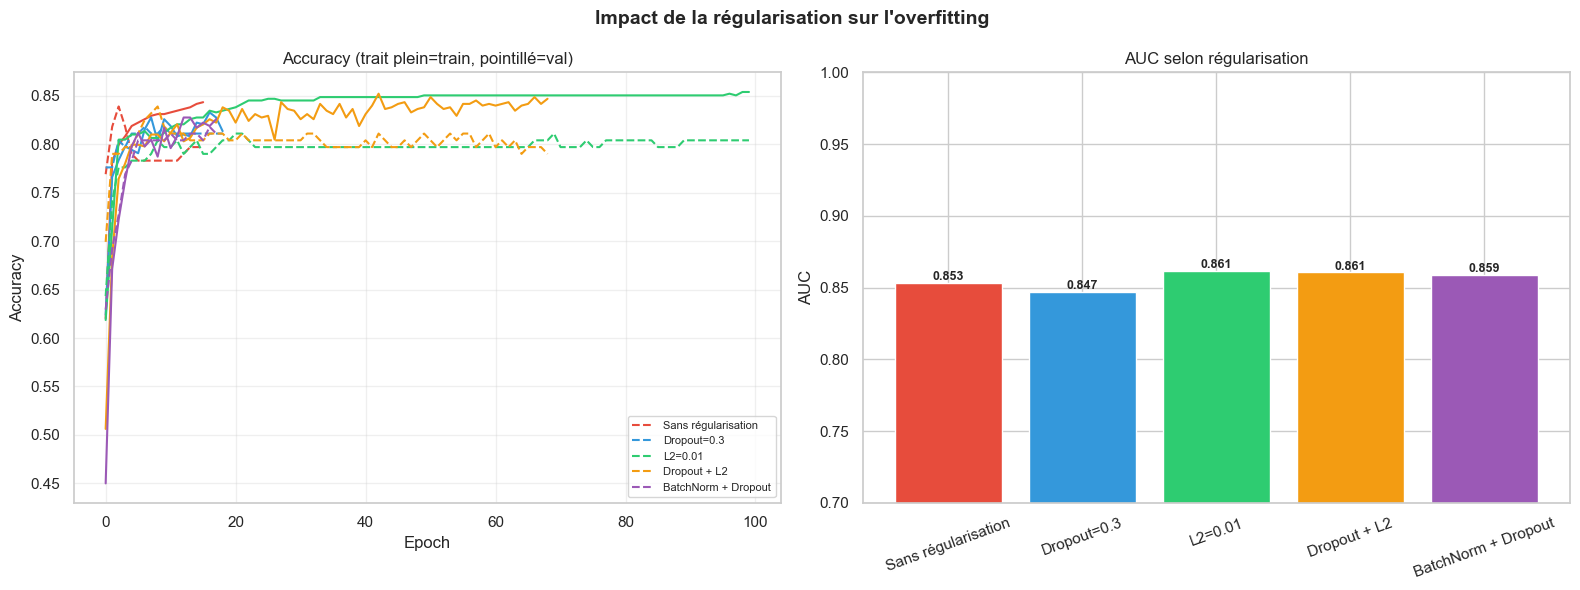

In [30]:
# Courbes overfitting : Train vs Val accuracy
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Impact de la régularisation sur l\'overfitting', fontsize=14, fontweight='bold')

colors_reg = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for r, color in zip(results_reg, colors_reg):
    h = r['history'].history
    axes[0].plot(h['accuracy'], color=color, linewidth=1.5, linestyle='-')
    axes[0].plot(h['val_accuracy'], color=color, linewidth=1.5, linestyle='--', 
                 label=r['name'])

axes[0].set_title('Accuracy (trait plein=train, pointillé=val)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Barre AUC finale
labels = [r['name'] for r in results_reg]
aucs = [r['auc'] for r in results_reg]
bars = axes[1].bar(labels, aucs, color=colors_reg, edgecolor='white')
axes[1].set_title('AUC selon régularisation')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('AUC')
for bar, val in zip(bars, aucs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('comparaison_regularisation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📐 Étape 15 — Analyse du Seuil de Classification (Q11)

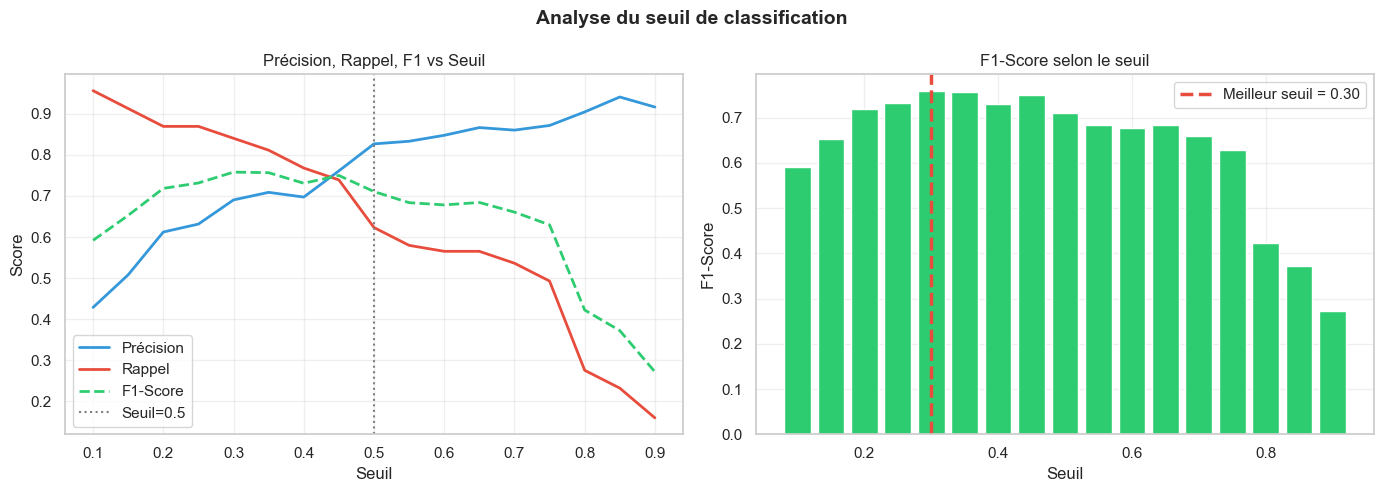


✅ Seuil optimal (max F1) : 0.30
   F1 correspondant       : 0.7582


In [31]:
from sklearn.metrics import precision_score, recall_score

# Prédictions du meilleur modèle
y_prob_base = model_base.predict(X_test, verbose=0).flatten()

thresholds = np.arange(0.1, 0.95, 0.05)
precisions, recalls, f1_scores = [], [], []

for t in thresholds:
    y_pred_t = (y_prob_base >= t).astype(int)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyse du seuil de classification', fontsize=14, fontweight='bold')

# Précision / Rappel selon le seuil
axes[0].plot(thresholds, precisions, label='Précision', color='#3498db', linewidth=2)
axes[0].plot(thresholds, recalls, label='Rappel', color='#e74c3c', linewidth=2)
axes[0].plot(thresholds, f1_scores, label='F1-Score', color='#2ecc71', linewidth=2, linestyle='--')
axes[0].axvline(x=0.5, color='gray', linestyle=':', label='Seuil=0.5')
axes[0].set_title('Précision, Rappel, F1 vs Seuil')
axes[0].set_xlabel('Seuil')
axes[0].set_ylabel('Score')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Seuil optimal (max F1)
best_threshold = thresholds[np.argmax(f1_scores)]
axes[1].bar(thresholds, f1_scores, width=0.04, color='#2ecc71', edgecolor='white')
axes[1].axvline(x=best_threshold, color='#e74c3c', linewidth=2.5, linestyle='--',
                label=f'Meilleur seuil = {best_threshold:.2f}')
axes[1].set_title('F1-Score selon le seuil')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('F1-Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analyse_seuil.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Seuil optimal (max F1) : {best_threshold:.2f}")
print(f"   F1 correspondant       : {max(f1_scores):.4f}")

---
## 🌲 Étape 16 — Comparaison avec d'autres modèles (Q12)

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

print("COMPARAISON AVEC D'AUTRES MODÈLES ML")
print("-" * 70)
print(f"  {'Modèle':25s} | Accuracy | F1      | AUC")
print("-" * 70)

# Modèles ML classiques
classical_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(probability=True, random_state=42),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
    'Régression Logistique': LogisticRegression(random_state=42, max_iter=500)
}

ml_results = []

for name, clf in classical_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]
    
    acc = (y_pred == y_test).mean()
    f1 = f1_score(y_test, y_pred)
    auc_s = roc_auc_score(y_test, y_prob)
    
    print(f"  {name:25s} | {acc:.4f}   | {f1:.4f}  | {auc_s:.4f}")
    ml_results.append({'name': name, 'accuracy': acc, 'f1': f1, 'auc': auc_s})

# RNA (modèle de base)
loss_nn, acc_nn = model_base.evaluate(X_test, y_test, verbose=0)
y_prob_nn = model_base.predict(X_test, verbose=0).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)
f1_nn = f1_score(y_test, y_pred_nn)
auc_nn = roc_auc_score(y_test, y_prob_nn)
print(f"  {'RNA (Keras)':25s} | {acc_nn:.4f}   | {f1_nn:.4f}  | {auc_nn:.4f}")
ml_results.append({'name': 'RNA (Keras)', 'accuracy': acc_nn, 'f1': f1_nn, 'auc': auc_nn})

COMPARAISON AVEC D'AUTRES MODÈLES ML
----------------------------------------------------------------------
  Modèle                    | Accuracy | F1      | AUC
----------------------------------------------------------------------
  Random Forest             | 0.8156   | 0.7519  | 0.8339
  SVM (RBF)                 | 0.8101   | 0.7167  | 0.8360
  KNN (k=5)                 | 0.8212   | 0.7538  | 0.8462
  Régression Logistique     | 0.8045   | 0.7244  | 0.8436
  RNA (Keras)               | 0.8045   | 0.7107  | 0.8523


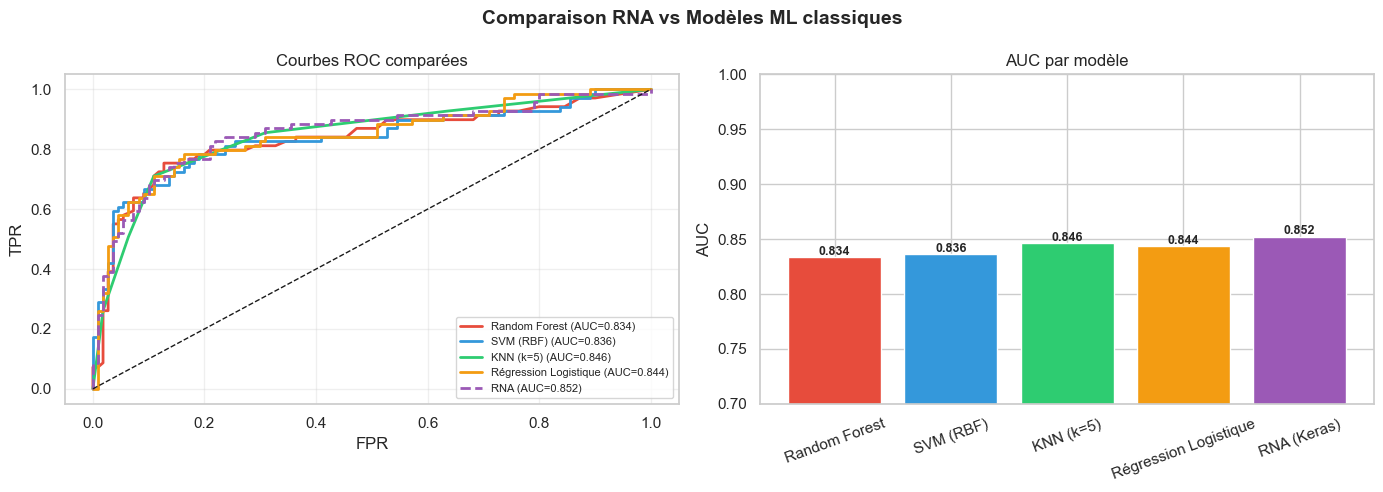

In [33]:
# Courbes ROC superposées
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison RNA vs Modèles ML classiques', fontsize=14, fontweight='bold')

colors_ml = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

# Courbes ROC
for clf, color, name in zip(list(classical_models.values()), colors_ml, list(classical_models.keys())):
    y_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_s = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc_s:.3f})', color=color, linewidth=2)

fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
axes[0].plot(fpr_nn, tpr_nn, label=f'RNA (AUC={auc_nn:.3f})', color='#9b59b6', linewidth=2, linestyle='--')
axes[0].plot([0,1],[0,1], 'k--', linewidth=1)
axes[0].set_title('Courbes ROC comparées')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Bar chart AUC
names_ml = [r['name'] for r in ml_results]
aucs_ml = [r['auc'] for r in ml_results]
colors_bars = colors_ml[:len(names_ml)]
bars = axes[1].bar(names_ml, aucs_ml, color=colors_bars, edgecolor='white')
axes[1].set_title('AUC par modèle')
axes[1].set_ylim(0.7, 1.0)
axes[1].set_ylabel('AUC')
for bar, val in zip(bars, aucs_ml):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
                 f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Étape 17 — Interprétation avec SHAP (Q13)

In [34]:
import shap

# SHAP avec le Random Forest (plus stable)
rf_model = classical_models['Random Forest']

# Créer l'explainer SHAP pour Random Forest
explainer = shap.TreeExplainer(rf_model)

# Calcul des valeurs SHAP (sur un sous-ensemble pour la vitesse)
X_test_df = pd.DataFrame(X_test, columns=X.columns)
shap_values = explainer.shap_values(X_test_df)

# Pour la classification binaire, shap_values[1] = classe positive (Survived=1)
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print("✅ Valeurs SHAP calculées avec succès !")
print(f"Shape des valeurs SHAP : {shap_vals.shape}")

✅ Valeurs SHAP calculées avec succès !
Shape des valeurs SHAP : (179, 8, 2)


<Figure size 1000x600 with 0 Axes>

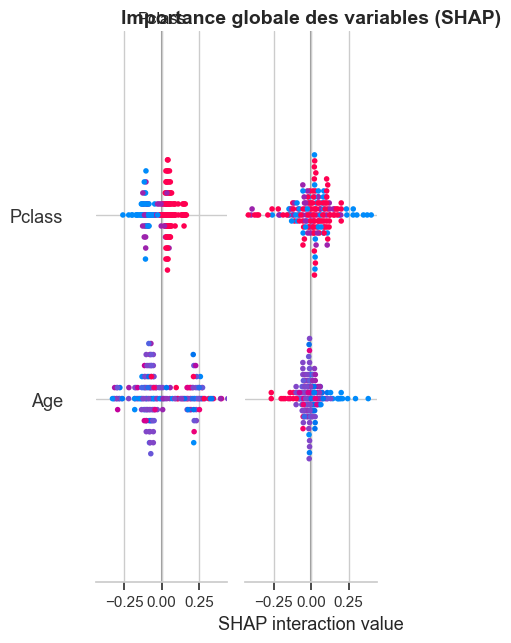

In [35]:
# Graphique 1 : Importance globale (Summary Plot)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_df, plot_type="bar", show=False)
plt.title('Importance globale des variables (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1000x600 with 0 Axes>

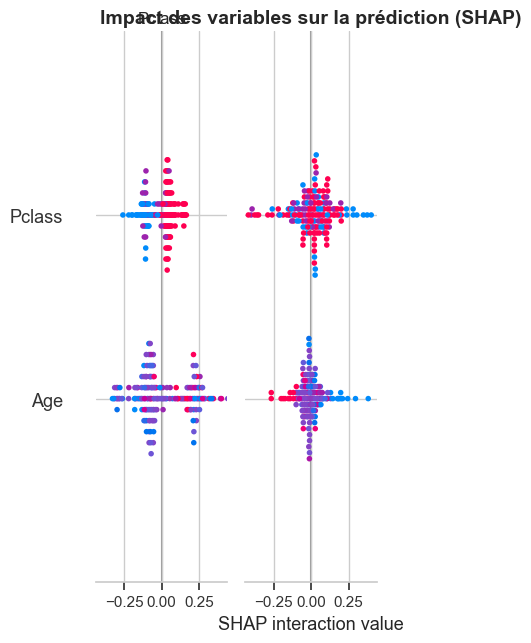

In [36]:
# Graphique 2 : Summary Plot (distribution des impacts)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals, X_test_df, show=False)
plt.title('Impact des variables sur la prédiction (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

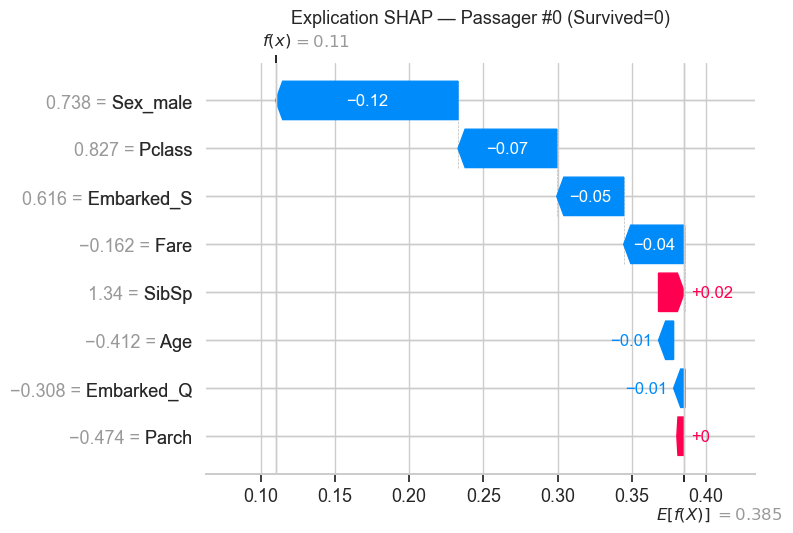

In [43]:
idx = 0  # First passenger

# Force base value to be a scalar (class 1)
if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_value = explainer.expected_value[1]
else:
    base_value = explainer.expected_value

# Extract SHAP values for class 1 → ensure 1D
values = shap_vals[idx][:, 1]

# Safety: force scalar
base_value = float(base_value)

plt.figure(figsize=(12, 4))
shap.waterfall_plot(
    shap.Explanation(
        values=values,
        base_values=base_value,
        data=X_test_df.iloc[idx].values,  # important fix
        feature_names=X.columns.tolist()
    ),
    show=False
)

plt.title(f'Explication SHAP — Passager #{idx} (Survived={y_test.iloc[idx]})', fontsize=13)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 📋 Étape 18 — Résumé Comparatif Final

In [44]:
# Tableau récapitulatif complet
print("\n" + "="*70)
print(" RÉSUMÉ FINAL — TOUTES LES EXPÉRIMENTATIONS")
print("="*70)

# Architectures
print("\n📐 ARCHITECTURES :")
for r in results_architectures:
    print(f"  {r['name']:30s} → Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f}")

# Activations
print("\n⚡ FONCTIONS D'ACTIVATION :")
for r in results_activations:
    print(f"  {r['name']:30s} → Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f}")

# Optimizers
print("\n⚙️ OPTIMIZERS :")
for r in results_optimizers:
    print(f"  {r['name']:30s} → Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f}")

# Régularisation
print("\n🛡️ RÉGULARISATION :")
for r in results_reg:
    print(f"  {r['name']:30s} → Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f}")

# Modèles ML
print("\n🌲 COMPARAISON MODÈLES ML :")
for r in ml_results:
    print(f"  {r['name']:30s} → Acc={r['accuracy']:.4f} | F1={r['f1']:.4f} | AUC={r['auc']:.4f}")


 RÉSUMÉ FINAL — TOUTES LES EXPÉRIMENTATIONS

📐 ARCHITECTURES :
  1 couche(s) cachée(s)          → Acc=0.7989 | F1=0.7049 | AUC=0.8448
  2 couche(s) cachée(s)          → Acc=0.7765 | F1=0.6721 | AUC=0.8489
  3 couche(s) cachée(s)          → Acc=0.7765 | F1=0.6923 | AUC=0.8468

⚡ FONCTIONS D'ACTIVATION :
  Activation : relu              → Acc=0.7989 | F1=0.7097 | AUC=0.8477
  Activation : tanh              → Acc=0.7877 | F1=0.6885 | AUC=0.8448
  Activation : elu               → Acc=0.7989 | F1=0.7000 | AUC=0.8585
  Activation : sigmoid           → Acc=0.7989 | F1=0.7049 | AUC=0.8395

⚙️ OPTIMIZERS :
  Optimizer : ADAM               → Acc=0.8045 | F1=0.7059 | AUC=0.8574
  Optimizer : SGD                → Acc=0.7933 | F1=0.6992 | AUC=0.8540
  Optimizer : RMSPROP            → Acc=0.7989 | F1=0.7049 | AUC=0.8598
  Optimizer : ADAGRAD            → Acc=0.7765 | F1=0.6825 | AUC=0.8120

🛡️ RÉGULARISATION :
  Sans régularisation            → Acc=0.7989 | F1=0.7097 | AUC=0.8531
  Dropout=0.3     

---
## 📝 Étape 19 — Réponses aux Questions du Compte-Rendu

### Q1 — Variables influençant le plus la survie
D'après l'analyse SHAP et les visualisations :
- **Sex_male** : Variable la plus déterminante. Les femmes avaient une probabilité de survie bien plus élevée.
- **Pclass** : La classe économique est très corrélée à la survie (1ère classe >> 3ème classe).
- **Fare** : Corrélé à Pclass, les tarifs élevés = survie plus probable.
- **Age** : Les jeunes enfants avaient une priorité d'évacuation.

### Q2 — Pourquoi encoder Sex et Embarked ?
Les réseaux de neurones ne peuvent traiter que des **valeurs numériques**. Les variables catégorielles comme 'male'/'female' sont des chaînes de caractères. L'encodage one-hot les transforme en colonnes binaires (0/1) interprétables mathématiquement.

### Q3 — Impact de la normalisation
La normalisation (StandardScaler) est **essentielle** car :
- Elle homogénéise les échelles (ex: Age 0-80 vs Fare 0-500)
- Elle accélère la convergence du gradient
- Elle évite que les features à grandes valeurs dominent l'apprentissage

### Q5 — Comparaison des fonctions d'activation
- **ReLU** : La plus rapide, pas de saturation pour les valeurs positives. Standard.
- **Tanh** : Centré en 0 (sortie entre -1 et 1), meilleur gradient en début d'entraînement.
- **ELU** : Comme ReLU mais lisse pour x<0, réduit le problème de "dying ReLU".
- **Sigmoid** : Réservée à la couche de sortie pour la classification binaire.

### Q6 — Comparaison des Optimizers
- **Adam** : Le meilleur compromis vitesse/stabilité. Recommandé par défaut.
- **SGD** : Convergence lente mais régulière. Bon avec momentum.
- **RMSprop** : Bon pour les données séquentielles/RNN, comparable à Adam ici.

### Q8 — Dropout et L2
- **Dropout** : Désactive aléatoirement des neurones pendant l'entraînement → force le réseau à ne pas sur-spécialiser.
- **L2 (Ridge)** : Pénalise les grands poids → lisse le modèle.
- Ensemble, ils **réduisent l'overfitting** mais peuvent légèrement baisser l'accuracy sur train.

### Q9 — Batch Normalization
Normalise les activations entre chaque couche → stabilise le gradient, permet des learning rates plus élevés, accélère la convergence.

### Q11 — Seuil optimal
- Seuil **> 0.5** → favorise la **précision** (moins de fausses alertes de survie)
- Seuil **< 0.5** → favorise le **rappel** (identifier davantage de survivants)
- Le seuil optimal (max F1) est calculé dans la cellule précédente.

### Q14 — La rétropropagation (Backpropagation)
1. **Forward pass** : Les données traversent le réseau, on obtient une prédiction
2. **Calcul de la loss** : On mesure l'erreur entre prédiction et vraie valeur
3. **Backward pass** : On calcule le gradient de l'erreur par rapport à chaque poids (règle de la chaîne)
4. **Mise à jour** : L'optimizer (Adam...) met à jour les poids dans le sens opposé au gradient
5. On répète pour chaque batch, chaque epoch

### Q15 — Entraînement trop long / trop court
- **Trop court (sous-apprentissage)** : Le modèle n'a pas convergé, erreur élevée sur train ET test
- **Trop long (sur-apprentissage)** : Le modèle mémorise le train set, bonne accuracy train mais mauvaise sur test
- **Solution** : EarlyStopping + Dropout + surveiller val_loss

In [45]:
print("✅ TP 7 — Réseaux de Neurones Artificiels — Terminé avec succès !")
print("\nFichiers générés :")
import os
for f in sorted(os.listdir('.')):
    if f.endswith('.png'):
        print(f"  📊 {f}")

✅ TP 7 — Réseaux de Neurones Artificiels — Terminé avec succès !

Fichiers générés :
  📊 Formal_Black_Suit_For_Professional_Identification_Needs__Suit__Formal__Id_PNG_Transparent_Image_and_Clipart_for_Free_Download-removebg-preview.png
  📊 Professional_Black_Suit_Passport_Style__Black_Suit__Formal_Suit__Passport_Size_Photo_PNG_Transparent_Image_and_Clipart_for_Free_Download-removebg-preview.png
  📊 analyse_seuil.png
  📊 artemis2_.png
  📊 comparaison_architectures.png
  📊 comparaison_lr.png
  📊 comparaison_modeles.png
  📊 comparaison_optimizers.png
  📊 comparaison_regularisation.png
  📊 courbes_modèle_de_base.png
  📊 ensaf_logo.png
  📊 etape1_agregation.png
  📊 etape2_standardisation.png
  📊 etape3_kmeans.png
  📊 etape4_dendrogrammes.png
  📊 etape4_ward.png
  📊 evaluation_modèle_de_base.png
  📊 exploration.png
  📊 fonctions_activation.png
  📊 gukeshVSnodirbek_showdown.png
  📊 hdpic-removebg-preview (1).png
  📊 hdpic-removebg-preview.png
  📊 my_pic-removebg-preview.png
  📊 q10_comparaiso